<div class="alert alert-block alert-success">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>

¡Hola Jose Luis!

Tu proyecto está aprobado. Lograste construir un análisis coherente de correlaciones para NovaRetail+, incluyendo exploración inicial, visualizaciones, Pearson/Spearman, punto-biserial, V de Cramér y hallazgos ejecutivos con enfoque no causal.

Como recomendación principal, cuida que cada evidencia numérica quede presentada con el mayor contexto posible: variable analizada, coeficiente, magnitud e interpretación. Esto hará que tus conclusiones sean más sólidas y útiles para una audiencia de negocio.

Saludos,  
Gina Buvoli
</div>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('data/novaretail_comportamiento_clientes_2024.csv', sep=';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- 'nivel_ingreso'
- 'visitas_mes'
- 'compras_mes'
- 'gasto_publicidad_dirigida'
- 'satisfacción'
- 'ingreso_anual'

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna 'edad' fue convertida de 'float64' a 'int64', quedando correctamente tipificada.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [7]:
# Corregir el tipo de dato
df["edad"] = df["edad"].astype(int)

In [8]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [12]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**:

Diagnóstico inicial de variables numéricas

- `edad` — Los clientes tienen entre 18 y 75 años, con una edad promedio de 38 años.
- `nivel_ingreso` — Presenta una amplia variabilidad, con ingresos entre 8.000 y 74.791 aproximadamente, y con un promedio de 30.019.
- `visitas_mes` — Los clientes realizan en promedio 10 visitas mensuales, con valores entre 1 y 25 visitas.
- `compras_mes` — La mayoría realiza pocas compras al mes (promedio de 1,2), aunque algunos clientes llegan a 8 compras.
- `gasto_publicidad_dirigida` — El gasto asignado varía entre 0 y 75,51, indicando distintos niveles de inversión publicitaria.
- `satisfaccion` — Se encuentra en una escala de 1 a 5, con un promedio cercano a 3,6, lo que refleja una satisfacción moderadamente alta.
- `ingreso_anual` — Presenta una alta variabilidad; algunos clientes no generan ingresos mientras que otros alcanzan valores considerablemente mayores de 244.690

#### Explorar variables binarias

In [14]:
# Verificar que cada columna tenga únicamente dos valores posibles
print(df["miembro_premium"].unique())
print(df["abandono"].unique())

[0 1]
[0 1]


✍️ **Comentario**

Diagnóstico inicial de variables binarias

- `miembro_premium` — Presenta únicamente los valores 0 y 1, por lo tanto está correctamente codoficada como variable binaria y no requiere transformación. 
- `abandono` — Presenta únicamente los valores 0 y 1, por lo tanto está correctamente codoficada como variable binaria y no requiere transformación.

#### Explorar variables categóricas

In [15]:
# Verificar el número de valores únicos por variable categórica
print(df["id_cliente"].nunique())
print(df["tipo_dispositivo"].nunique())
print(df["region"].nunique())

15000
3
4


In [16]:
# Explorar variables categóricas y cómo se distribuyen
print(df["tipo_dispositivo"].value_counts())
print()

print(df["region"].value_counts())

móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Existen 3 categorías (móvil, escritorio y tablet). El dispositivo más utilizado es **móvil** con 9.818 clientes, seguido de **escritorio** (3.720) y **tablet** (1.462).

- `region` — Existen 4 regiones (norte, sur, este y oeste). La distribución es relativamente equilibrada, aunque **norte** concentra la mayor cantidad de clientes (4.395) y **este** la menor (3.069).

- `id_cliente` — Se identifican **15.000 valores únicos**, confirmando que cada cliente posee un identificador único y no existen registros duplicados.


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

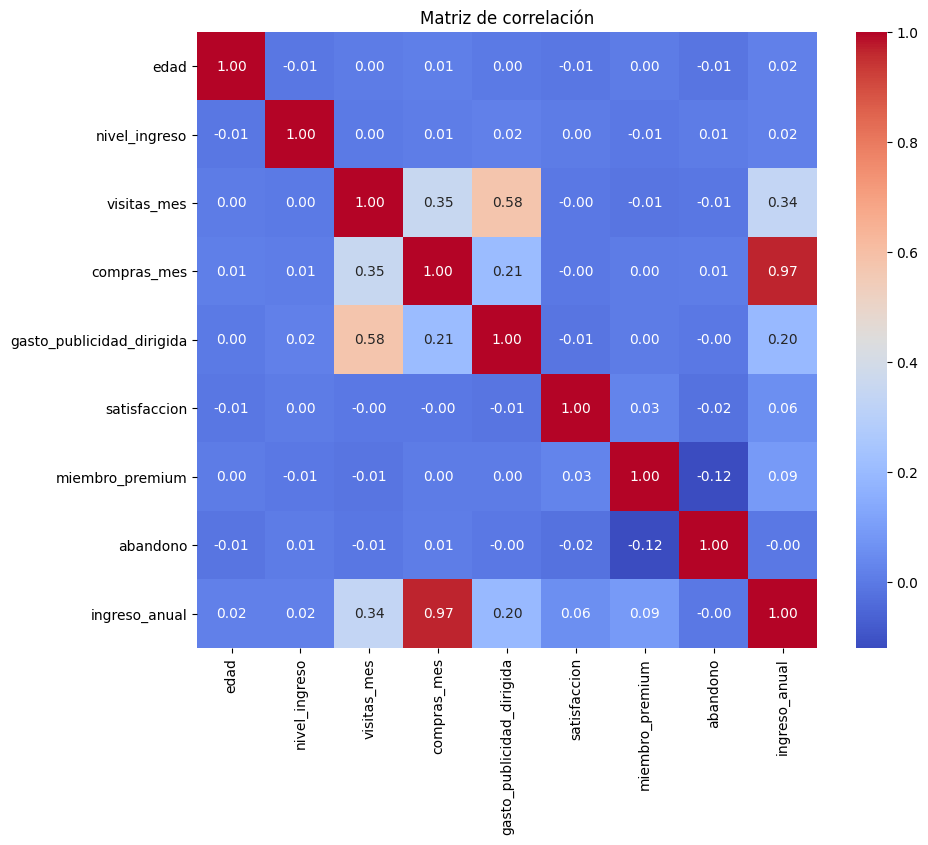

In [18]:
# Visualizar la matriz de correlación para identificar relaciones
# Visualizar la matriz de correlación para identificar relaciones

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

✍️ **Comentario**

Observaciones generales (Heatmap)  
- La mayoría de las variables presentan correlaciones bajas o cercanas a cero.
- Se observa una correlación positiva muy fuerte entre `compras_mes` e `ingreso_anual` (0.97).
- También existe una correlación positiva moderada entre `visitas_mes` y `gasto_publicidad_dirigida` (0.58).


Observaciones respecto a `ingreso_anual`  
-`ingreso_anual` presenta una relación muy fuerte con `compras_mes` (0.97), una relación moderada con `visitas_mes` (0.34) y una relación débil con `gasto_publicidad_dirigida` (0.20).
- Las demás variables muestran correlaciones muy bajas con `ingreso_anual`.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

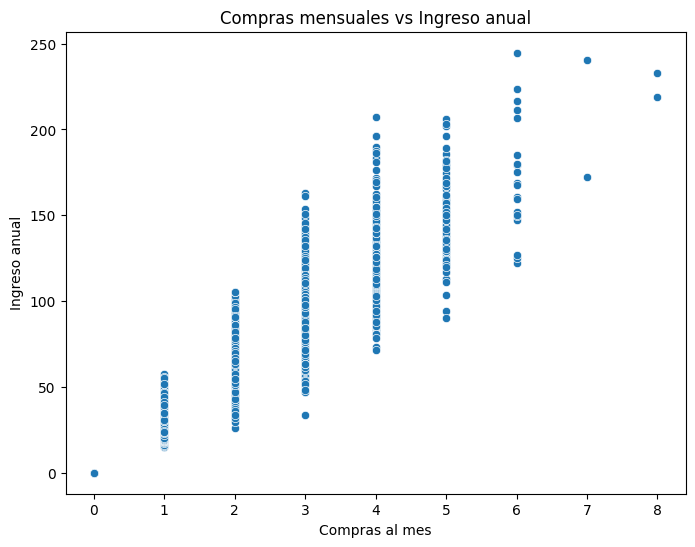

In [19]:
# Scatterplot general

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="compras_mes",
    y="ingreso_anual"
)

plt.title("Compras mensuales vs Ingreso anual")
plt.xlabel("Compras al mes")
plt.ylabel("Ingreso anual")
plt.show()

### Observaciones iniciales (Scatterplot)

El gráfico muestra una relación positiva entre **compras_mes** e **ingreso_anual**. En general, los clientes que realizan más compras al mes generan mayores ingresos anuales.

### Scatterplot para pares clave

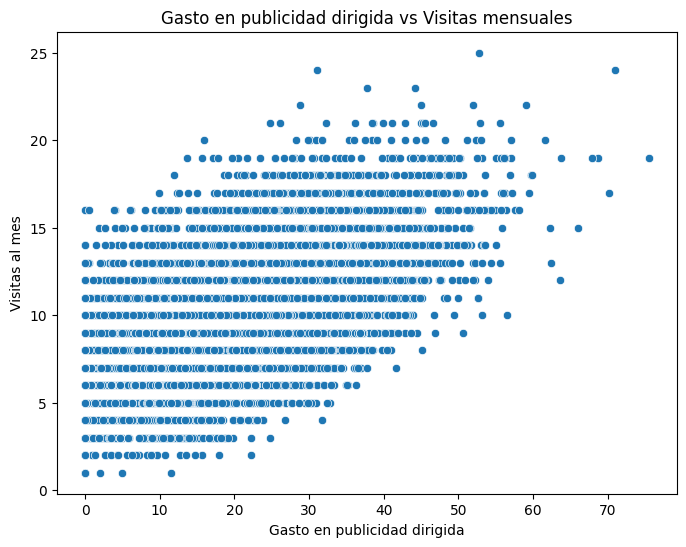

In [20]:
# Visualizar pares de variables con relaciones moderadas o fuertes
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="gasto_publicidad_dirigida",
    y="visitas_mes"
)

plt.title("Gasto en publicidad dirigida vs Visitas mensuales")
plt.xlabel("Gasto en publicidad dirigida")
plt.ylabel("Visitas al mes")

plt.show()

✍️ **Comentario**

Observaciones iniciales (Scatterplot)

**var1 vs var2**
**compras_mes vs ingreso_anual**
- Dirección Positiva.
- Se observa una relación lineal fuerte; a mayor número de compras mensuales, mayor ingreso anual generado por el cliente.
- 

**var1 vs var3**
**gasto_publicidad_dirigida vs visitas_mes**
- Dirección Positiva.
- La relación presenta una dispersión media. En general, un mayor gasto en publicidad dirigida se asocia con un mayor número de visitas mensuales, aunque existe variabilidad entre clientes.
- 

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [21]:
# Calcular correlación entre variables relevantes

pearson = df[["compras_mes", "ingreso_anual"]].corr(method="pearson")
spearman = df[["compras_mes", "ingreso_anual"]].corr(method="spearman")

print("Pearson")
print(pearson)

print()

print("Spearman")
print(spearman)

Pearson
               compras_mes  ingreso_anual
compras_mes       1.000000       0.967149
ingreso_anual     0.967149       1.000000

Spearman
               compras_mes  ingreso_anual
compras_mes       1.000000       0.967482
ingreso_anual     0.967482       1.000000


In [22]:
# Calcular correlación entre variables relevantes

pearson2 = df[["gasto_publicidad_dirigida", "visitas_mes"]].corr(method="pearson")
spearman2 = df[["gasto_publicidad_dirigida", "visitas_mes"]].corr(method="spearman")

print("Pearson")
print(pearson2)

print()

print("Spearman")
print(spearman2)

Pearson
                           gasto_publicidad_dirigida  visitas_mes
gasto_publicidad_dirigida                   1.000000     0.578947
visitas_mes                                 0.578947     1.000000

Spearman
                           gasto_publicidad_dirigida  visitas_mes
gasto_publicidad_dirigida                   1.000000     0.559267
visitas_mes                                 0.559267     1.000000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**compras_mes vs ingreso_anual**

**var1 vs var2**
- Correlación positiva muy fuerte (Pearson = 0.967; Spearman = 0.967).
- Ambos coeficientes son prácticamente iguales, lo que indica una relación muy consistente entre ambas variables y una posible colinealidad.

**gasto_publicidad_dirigida vs visitas_mes**

**var2 vs var3**
- Correlación positiva moderada (Pearson = 0.579; Spearman = 0.559).
- Los coeficientes son similares, lo que indica una asociación positiva estable, aunque considerablemente menor que la observada entre compras e ingreso anual.

### Punto-biserial

In [23]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

corr_premium, p_premium = pointbiserialr(df["miembro_premium"], df["ingreso_anual"])

corr_abandono, p_abandono = pointbiserialr(df["abandono"], df["ingreso_anual"])

print("Miembro premium")
print("Correlación:", corr_premium)
print("p-valor:", p_premium)

print()

print("Abandono")
print("Correlación:", corr_abandono)
print("p-valor:", p_abandono)

Miembro premium
Correlación: 0.0930994396198015
p-valor: 3.0943076155242597e-30

Abandono
Correlación: -0.002823934021617148
p-valor: 0.7294691719078393


✍️ **Comentario**

Observaciones Punto-biserial
**miembro_premium vs ingreso_anual**

**var1 vs var2**
- **Dirección:** Positiva.
- **Magnitud:** Muy débil (r = 0.093).
- Existe una ligera asociación entre ser miembro premium y el ingreso anual. Aunque la correlación es positiva, su magnitud es muy baja, por lo que el impacto práctico es pequeño. El p-valor es muy bajo, indicando que la relación es estadísticamente significativa.

**abandono vs ingreso_anual**

**var2 vs var3**
- **Dirección:** Negativa.
- **Magnitud:** Prácticamente nula (r = -0.003).
- No se observa una relación relevante entre el abandono del cliente y el ingreso anual. El p-valor (0.729) indica que la relación no es estadísticamente significativa.

### V de Cramér

In [26]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(tabla):
    chi2, p, dof, expected = chi2_contingency(tabla)
    n = tabla.sum().sum()
    k = min(tabla.shape) - 1
    v = np.sqrt(chi2 / (n * k))
    return v, p

In [27]:
# Aplicar V de Cramér en variables relevantes
tabla = pd.crosstab(
    df["region"],
    df["tipo_dispositivo"]
)

print(tabla)

v, p = cramers_v(tabla)

print("\nV de Cramér:", round(v, 4))
print("p-valor:", p)



tipo_dispositivo  escritorio  móvil  tablet
region                                     
este                     766   2003     300
norte                   1125   2843     427
oeste                    935   2489     386
sur                      894   2483     349

V de Cramér: 0.0124
p-valor: 0.5964767124605646


✍️ **Comentario**

Observaciones V de Cramér
**Región vs tipo_dispositivo**

- Magnitud: Muy baja (V de Cramér = 0.0124).
- El p-valor (0.5965) es mayor que 0.05, por lo que no existe evidencia de una asociación estadísticamente significativa entre ambas variables.
- En consecuencia, la región del cliente no parece estar relacionada con el tipo de dispositivo utilizado.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — 

**Evidencia visual:**   
- Heatmap y scatterplot de compras_mes vs ingreso_anual.

**Evidencia numérica:** 
- Pearson = 0.967
- Spearman = 0.967

**Interpretación**  
- Se observa una relación positiva muy fuerte entre el número de compras mensuales y el ingreso anual generado por los clientes. Los resultados son consistentes tanto con Pearson como con Spearman.

**No podemos afirmar**  
- No podemos concluir que realizar más compras sea la causa directa de un mayor ingreso anual, ya que el análisis es correlacional y no demuestra causalidad.

**Implicación de negocio**  
- La empresa podría enfocar estrategias para aumentar la frecuencia de compra de sus clientes, ya que esta variable está fuertemente asociada con mayores ingresos anuales.

### Hallazgo 2 — 

**Evidencia visual:**   
- Scatterplot de gasto_publicidad_dirigida vs visitas_mes y tabla de contingencia para región vs tipo_dispositivo.

**Evidencia numérica:** 
- Pearson = 0.579
- Spearman = 0.559
- Punto-biserial (miembro premium) = 0.093, p < 0.05
- V de Cramér = 0.012, p = 0.596

**Interpretación**  
- La publicidad dirigida presenta una relación positiva moderada con las visitas mensuales. En cambio, la condición de miembro premium tiene una relación positiva pero débil con el ingreso anual, y no se observa una asociación relevante entre la región y el tipo de dispositivo utilizado.

**No podemos afirmar**  
- No podemos asegurar que la publicidad aumente las visitas, que ser miembro premium incremente el ingreso anual o que la región influya en el tipo de dispositivo utilizado, ya que el análisis es únicamente correlacional. 

**Implicación de negocio**  
- La empresa podría evaluar campañas para incrementar las visitas mediante publicidad dirigida y seguir analizando el programa premium. No sería prioritario segmentar campañas según la región y el tipo de dispositivo, ya que no se encontró una asociación significativa.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**

- El análisis realizado es correlacional, por lo que no permite establecer relaciones de causa y efecto entre las variables.
- Los resultados dependen de la calidad y representatividad del conjunto de datos analizado.
- Algunas relaciones observadas son débiles o no significativas, por lo que deben interpretarse con cautela.

### **Próximos pasos** 

**Profundizar la segmentación de clientes**

- Analizar los resultados por grupos de edad.
- Comparar el comportamiento según el nivel de ingresos.

**Validar los hallazgos**

- Realizar pruebas A/B para evaluar si aumentar la publicidad dirigida incrementa realmente las visitas o las compras.

**Ampliar el análisis**

- Incorporar nuevas variables, como historial de compras, campañas de marketing o antigüedad del cliente, para comprender mejor los factores asociados al ingreso anual.